<a href="https://www.kaggle.com/code/kausar15027/forhad-research?scriptVersionId=315069960" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

   Year  Month  Temperature  Precipitation       Date
0  1901      1      16.9760        18.5356 1901-01-01
1  1901      2      19.9026        16.2548 1901-02-01
2  1901      3      24.3158        70.7981 1901-03-01
3  1901      4      28.1834        66.1616 1901-04-01
4  1901      5      27.8892       267.2150 1901-05-01
      Year  Month  Temperature  Precipitation       Date
1375  2015      8      28.0642      512.12700 2015-08-01
1376  2015      9      28.1230      353.86900 2015-09-01
1377  2015     10      26.8624       81.59940 2015-10-01
1378  2015     11      23.1842        4.60815 2015-11-01
1379  2015     12      18.7124        5.97798 2015-12-01

Temperature Model Results
------------------------------
R²   : 0.9815
MAE  : 0.3734
RMSE : 0.4950

Precipitation Model Results
------------------------------
R²   : 0.8761
MAE  : 41.2031
RMSE : 68.1424


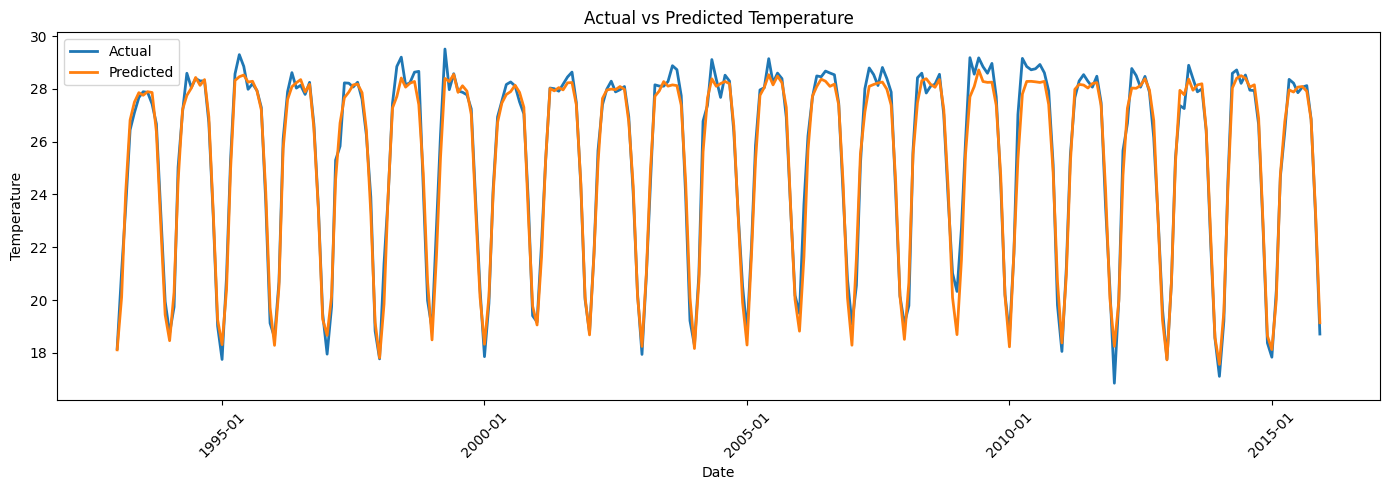

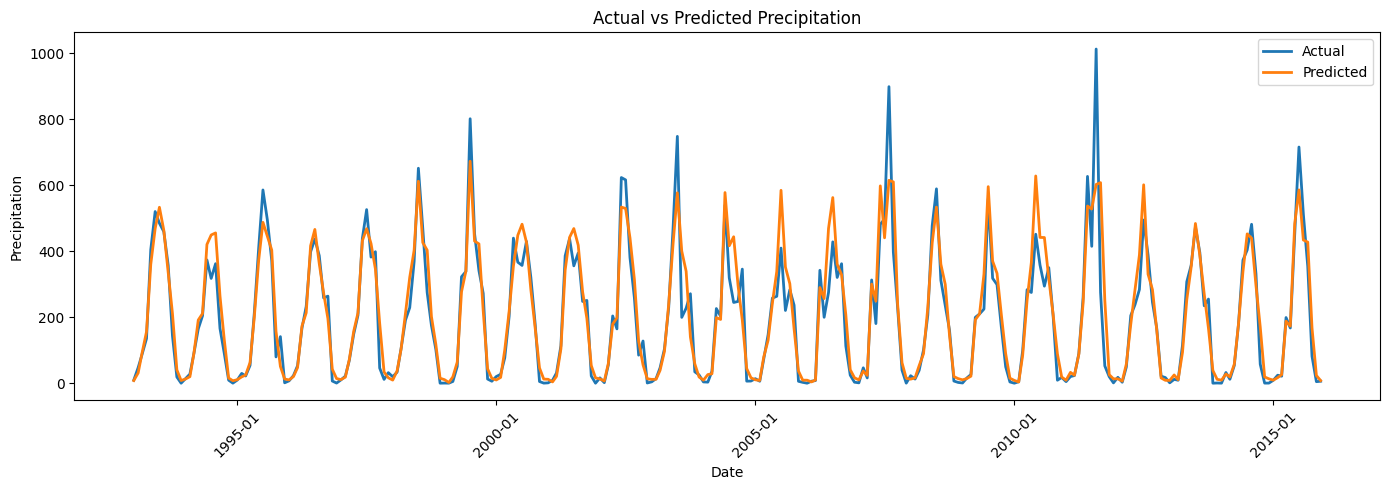

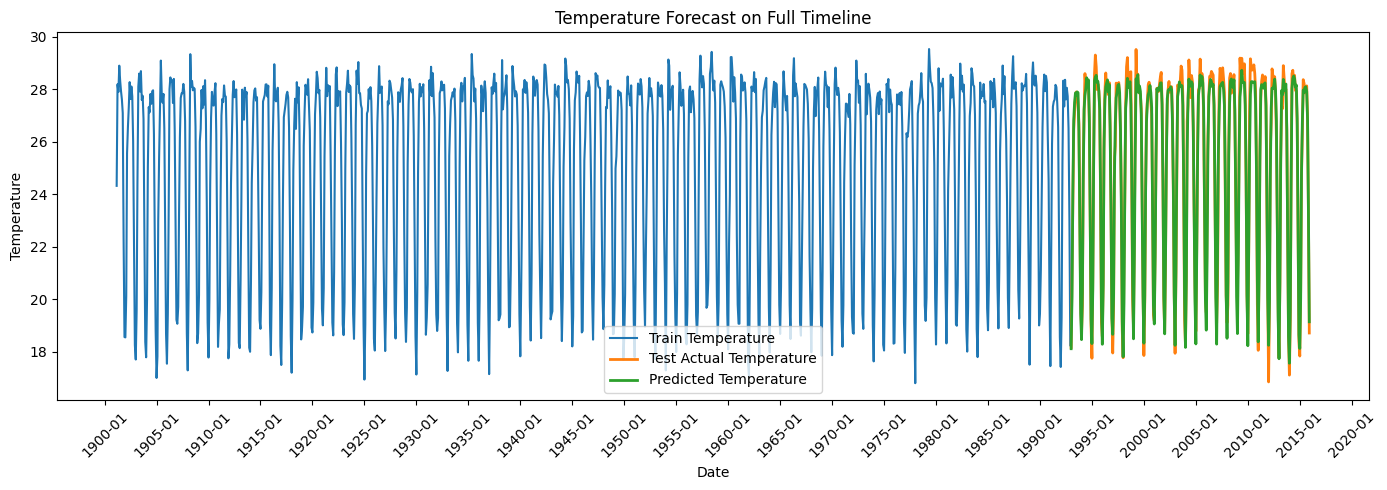

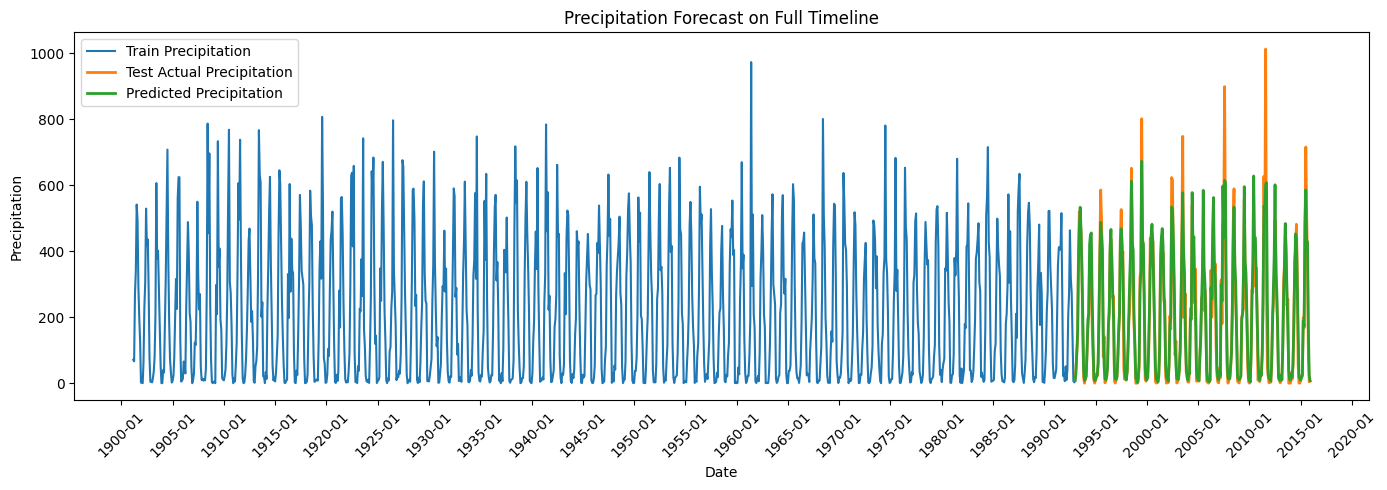


Next Month Forecast
------------------------------
Forecast Date         : 2016-01
Predicted Temperature : 19.293
Predicted Precipitation: 8.452


In [1]:
import pandas as pd
import numpy as np
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# =====================================================
# 1. LOAD DATA
# =====================================================
df = pd.read_csv("/kaggle/input/datasets/mdforhadmia/temp-and-rain-csv/Temp_and_rain.csv")

# Create proper date column
df["Date"] = pd.to_datetime(df[["Year", "Month"]].assign(DAY=1))

# Sort chronologically
df = df.sort_values("Date").reset_index(drop=True)

print(df.head())
print(df.tail())

# =====================================================
# 2. FEATURE ENGINEERING
# =====================================================
# Cyclical month encoding
df["Month_sin"] = np.sin(2 * np.pi * df["Month"] / 12)
df["Month_cos"] = np.cos(2 * np.pi * df["Month"] / 12)

# Lag and rolling features for temperature
df["Temp_lag1"] = df["Temperature"].shift(1)
df["Temp_roll3"] = df["Temperature"].rolling(3).mean()

# Lag and rolling features for precipitation
df["Prec_lag1"] = df["Precipitation"].shift(1)
df["Prec_roll3"] = df["Precipitation"].rolling(3).mean()

# Drop rows with NaN caused by lag/rolling
df = df.dropna().reset_index(drop=True)

# =====================================================
# 3. FEATURE SETS
# =====================================================
temp_features = [
    "Year", "Month_sin", "Month_cos",
    "Temp_lag1", "Temp_roll3",
    "Prec_lag1", "Prec_roll3"
]

prec_features = [
    "Year", "Month_sin", "Month_cos",
    "Temp_lag1", "Temp_roll3",
    "Prec_lag1", "Prec_roll3"
]

X_temp = df[temp_features]
y_temp = df["Temperature"]

X_prec = df[prec_features]
y_prec = df["Precipitation"]

dates = df["Date"]

# =====================================================
# 4. TRAIN / TEST SPLIT (TIME SERIES: NO SHUFFLE)
# =====================================================
train_size = int(len(df) * 0.8)

X_temp_train = X_temp.iloc[:train_size]
X_temp_test = X_temp.iloc[train_size:]
y_temp_train = y_temp.iloc[:train_size]
y_temp_test = y_temp.iloc[train_size:]

X_prec_train = X_prec.iloc[:train_size]
X_prec_test = X_prec.iloc[train_size:]
y_prec_train = y_prec.iloc[:train_size]
y_prec_test = y_prec.iloc[train_size:]

dates_train = dates.iloc[:train_size]
dates_test = dates.iloc[train_size:]

# =====================================================
# 5. MODELS
# =====================================================
temp_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

prec_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

# Train
temp_model.fit(X_temp_train, y_temp_train)
prec_model.fit(X_prec_train, y_prec_train)

# Predict
temp_pred = temp_model.predict(X_temp_test)
prec_pred = prec_model.predict(X_prec_test)

# =====================================================
# 6. EVALUATION
# =====================================================
def evaluate_model(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    print(f"\n{name} Results")
    print("-" * 30)
    print(f"R²   : {r2:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")

evaluate_model("Temperature Model", y_temp_test, temp_pred)
evaluate_model("Precipitation Model", y_prec_test, prec_pred)

# =====================================================
# 7. PLOT FUNCTION WITH DATE ON X-AXIS
# =====================================================
def plot_actual_vs_pred(dates, actual, predicted, ylabel, title):
    plt.figure(figsize=(14, 5))
    plt.plot(dates, actual, label="Actual", linewidth=2)
    plt.plot(dates, predicted, label="Predicted", linewidth=2)
    
    plt.xlabel("Date")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.YearLocator(5))   # every 5 years
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

# =====================================================
# 8. PLOTS
# =====================================================
plot_actual_vs_pred(
    dates_test,
    y_temp_test.values,
    temp_pred,
    ylabel="Temperature",
    title="Actual vs Predicted Temperature"
)

plot_actual_vs_pred(
    dates_test,
    y_prec_test.values,
    prec_pred,
    ylabel="Precipitation",
    title="Actual vs Predicted Precipitation"
)

# =====================================================
# 9. FULL TIMELINE PLOT
# =====================================================
plt.figure(figsize=(14, 5))
plt.plot(dates_train, y_temp_train.values, label="Train Temperature", linewidth=1.5)
plt.plot(dates_test, y_temp_test.values, label="Test Actual Temperature", linewidth=2)
plt.plot(dates_test, temp_pred, label="Predicted Temperature", linewidth=2)

plt.xlabel("Date")
plt.ylabel("Temperature")
plt.title("Temperature Forecast on Full Timeline")
plt.legend()

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(dates_train, y_prec_train.values, label="Train Precipitation", linewidth=1.5)
plt.plot(dates_test, y_prec_test.values, label="Test Actual Precipitation", linewidth=2)
plt.plot(dates_test, prec_pred, label="Predicted Precipitation", linewidth=2)

plt.xlabel("Date")
plt.ylabel("Precipitation")
plt.title("Precipitation Forecast on Full Timeline")
plt.legend()

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# =====================================================
# 10. NEXT MONTH FORECAST
# =====================================================
last_row = df.iloc[-1]
last_date = last_row["Date"]

next_date = last_date + pd.DateOffset(months=1)
next_year = next_date.year
next_month = next_date.month

# For rolling features, use last available 3 rows
last_3_temp_mean = df["Temperature"].iloc[-3:].mean()
last_3_prec_mean = df["Precipitation"].iloc[-3:].mean()

future_features = pd.DataFrame({
    "Year": [next_year],
    "Month_sin": [np.sin(2 * np.pi * next_month / 12)],
    "Month_cos": [np.cos(2 * np.pi * next_month / 12)],
    "Temp_lag1": [df["Temperature"].iloc[-1]],
    "Temp_roll3": [last_3_temp_mean],
    "Prec_lag1": [df["Precipitation"].iloc[-1]],
    "Prec_roll3": [last_3_prec_mean]
})

future_temp = temp_model.predict(future_features)[0]
future_prec = prec_model.predict(future_features)[0]

print("\nNext Month Forecast")
print("-" * 30)
print("Forecast Date         :", next_date.strftime("%Y-%m"))
print("Predicted Temperature :", round(future_temp, 3))
print("Predicted Precipitation:", round(future_prec, 3))



2026-04-28 14:05:21.904241: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777385122.111012      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777385122.169176      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777385122.631819      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777385122.631873      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777385122.631877      16 computation_placer.cc:177] computation placer alr

   Year  Month  Temperature  Precipitation       Date
0  1901      1      16.9760        18.5356 1901-01-01
1  1901      2      19.9026        16.2548 1901-02-01
2  1901      3      24.3158        70.7981 1901-03-01
3  1901      4      28.1834        66.1616 1901-04-01
4  1901      5      27.8892       267.2150 1901-05-01
X_seq shape: (1368, 12, 3)
y_seq shape: (1368, 2)
Epoch 1/100


2026-04-28 14:05:43.917308: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.1582 - val_loss: 0.0180
Epoch 2/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0133 - val_loss: 0.0140
Epoch 3/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0091 - val_loss: 0.0071
Epoch 4/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0064 - val_loss: 0.0074
Epoch 5/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0062 - val_loss: 0.0067
Epoch 6/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0056 - val_loss: 0.0062
Epoch 7/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0052 - val_loss: 0.0107
Epoch 8/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0057 - val_loss: 0.0067
Epoch 9/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0050 - val_loss: 0.0059
Epoch 10/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0051 - val_loss: 0.0081
Epoch 11/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0052 - val_loss: 0.0063
Epoch 12/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0

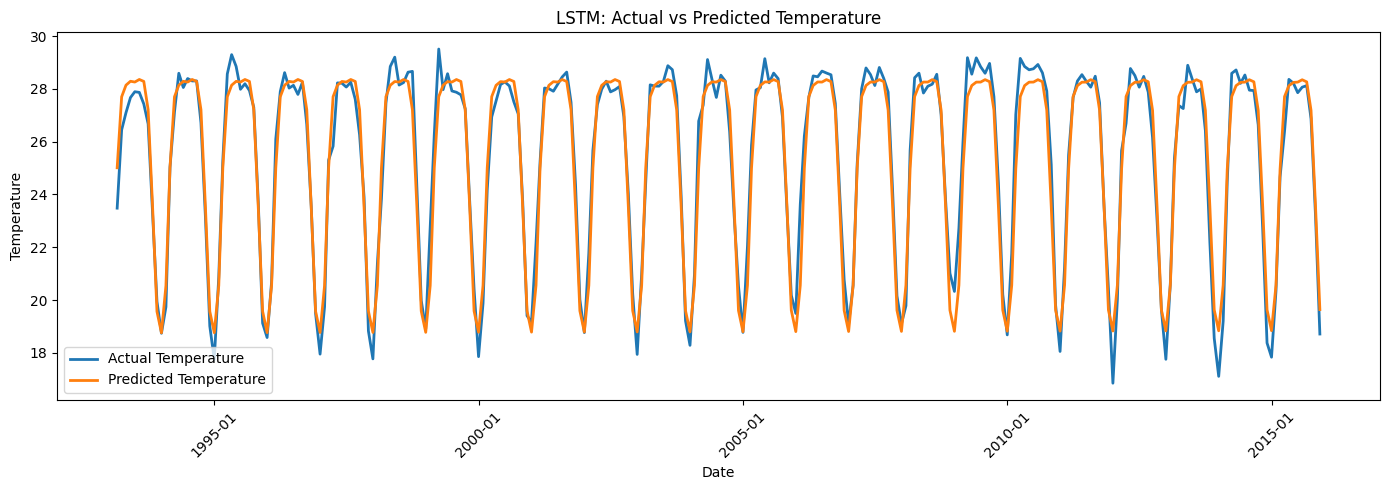

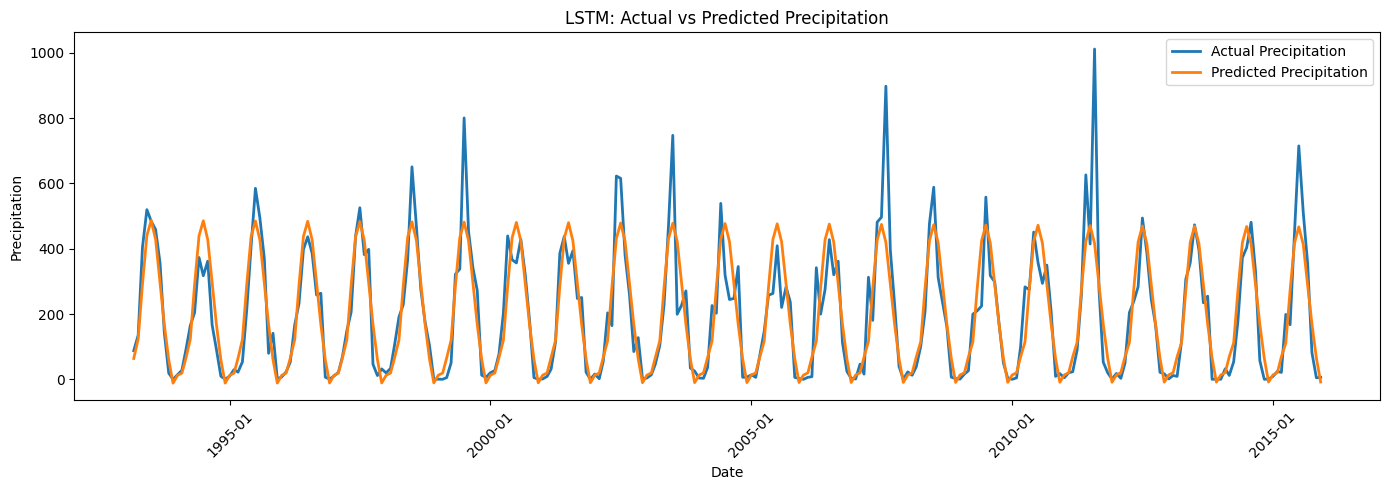

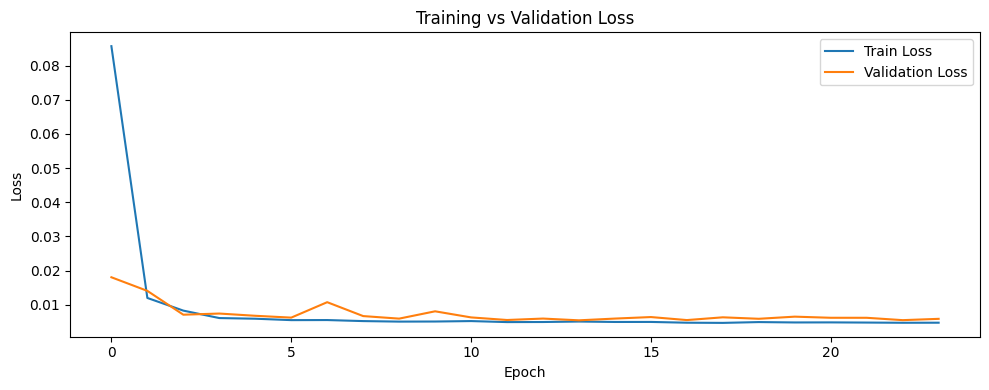

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

Next Month Forecast
------------------------------
Forecast Date          : 2016-01
Predicted Temperature  : 18.842
Predicted Precipitation: 13.623


In [2]:
import pandas as pd
import numpy as np
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping

# =====================================================
# 1. LOAD DATA
# =====================================================
df = pd.read_csv("/kaggle/input/datasets/mdforhadmia/temp-and-rain-csv/Temp_and_rain.csv")

# Create Date column
df["Date"] = pd.to_datetime(df[["Year", "Month"]].assign(DAY=1))

# Sort by time
df = df.sort_values("Date").reset_index(drop=True)

print(df.head())

# =====================================================
# 2. FEATURE ENGINEERING
# =====================================================
# Cyclical month encoding
df["Month_sin"] = np.sin(2 * np.pi * df["Month"] / 12)
df["Month_cos"] = np.cos(2 * np.pi * df["Month"] / 12)

# Feature columns
feature_cols = ["Year", "Month_sin", "Month_cos"]

# Target columns
target_cols = ["Temperature", "Precipitation"]

X = df[feature_cols]
y = df[target_cols]

# =====================================================
# 3. SCALE DATA
# =====================================================
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

# =====================================================
# 4. CREATE SEQUENCES
# =====================================================
def create_sequences(X, y, dates, time_steps=12):
    Xs, ys, ds = [], [], []
    
    for i in range(len(X) - time_steps):
        Xs.append(X[i:i+time_steps])
        ys.append(y[i+time_steps])
        ds.append(dates.iloc[i+time_steps])
        
    return np.array(Xs), np.array(ys), np.array(ds)

time_steps = 12   # use past 12 months to predict next month

X_seq, y_seq, date_seq = create_sequences(X_scaled, y_scaled, df["Date"], time_steps=time_steps)

print("X_seq shape:", X_seq.shape)
print("y_seq shape:", y_seq.shape)

# =====================================================
# 5. TRAIN / TEST SPLIT (CHRONOLOGICAL)
# =====================================================
split = int(len(X_seq) * 0.8)

X_train = X_seq[:split]
X_test = X_seq[split:]

y_train = y_seq[:split]
y_test = y_seq[split:]

dates_train = date_seq[:split]
dates_test = date_seq[split:]

# =====================================================
# 6. BUILD LSTM MODEL
# =====================================================
model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(64, return_sequences=True),
    LSTM(32),
    Dense(16, activation="relu"),
    Dense(2)   # 2 outputs: Temperature, Precipitation
])

model.compile(optimizer="adam", loss="mse")

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# =====================================================
# 7. TRAIN MODEL
# =====================================================
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

# =====================================================
# 8. PREDICT
# =====================================================
y_pred = model.predict(X_test)

# Convert back to original scale
y_test_inv = scaler_y.inverse_transform(y_test)
y_pred_inv = scaler_y.inverse_transform(y_pred)

# Separate outputs
temp_actual = y_test_inv[:, 0]
temp_pred = y_pred_inv[:, 0]

prec_actual = y_test_inv[:, 1]
prec_pred = y_pred_inv[:, 1]

# =====================================================
# 9. EVALUATION
# =====================================================
def evaluate_model(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    print(f"\n{name}")
    print("-" * 30)
    print(f"R²   : {r2:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")

evaluate_model("Temperature Forecast", temp_actual, temp_pred)
evaluate_model("Precipitation Forecast", prec_actual, prec_pred)

# =====================================================
# 10. PLOT TEMPERATURE WITH DATE ON X-AXIS
# =====================================================
plt.figure(figsize=(14, 5))
plt.plot(dates_test, temp_actual, label="Actual Temperature", linewidth=2)
plt.plot(dates_test, temp_pred, label="Predicted Temperature", linewidth=2)

plt.xlabel("Date")
plt.ylabel("Temperature")
plt.title("LSTM: Actual vs Predicted Temperature")
plt.legend()

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# =====================================================
# 11. PLOT PRECIPITATION WITH DATE ON X-AXIS
# =====================================================
plt.figure(figsize=(14, 5))
plt.plot(dates_test, prec_actual, label="Actual Precipitation", linewidth=2)
plt.plot(dates_test, prec_pred, label="Predicted Precipitation", linewidth=2)

plt.xlabel("Date")
plt.ylabel("Precipitation")
plt.title("LSTM: Actual vs Predicted Precipitation")
plt.legend()

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# =====================================================
# 12. TRAINING LOSS PLOT
# =====================================================
plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

# =====================================================
# 13. FORECAST NEXT MONTH
# =====================================================
last_sequence = X_scaled[-time_steps:]
last_sequence = last_sequence.reshape(1, time_steps, X.shape[1])

future_pred_scaled = model.predict(last_sequence)
future_pred = scaler_y.inverse_transform(future_pred_scaled)

last_date = df["Date"].iloc[-1]
next_date = last_date + pd.DateOffset(months=1)

print("\nNext Month Forecast")
print("-" * 30)
print("Forecast Date          :", next_date.strftime("%Y-%m"))
print("Predicted Temperature  :", round(future_pred[0][0], 3))
print("Predicted Precipitation:", round(future_pred[0][1], 3))


Next 5 Years Forecast
        Date  Predicted_Temperature  Predicted_Precipitation
0 2016-01-01              18.842216                13.623127
1 2016-02-01              20.567404                20.714022
2 2016-03-01              24.938929                69.143707
3 2016-04-01              27.708849               110.495934
4 2016-05-01              28.118547               270.756989
         Date  Predicted_Temperature  Predicted_Precipitation
55 2020-08-01              28.340611               409.789307
56 2020-09-01              28.259224               285.432983
57 2020-10-01              27.172235               169.719757
58 2020-11-01              23.553167                67.023079
59 2020-12-01              19.652218                -7.471733


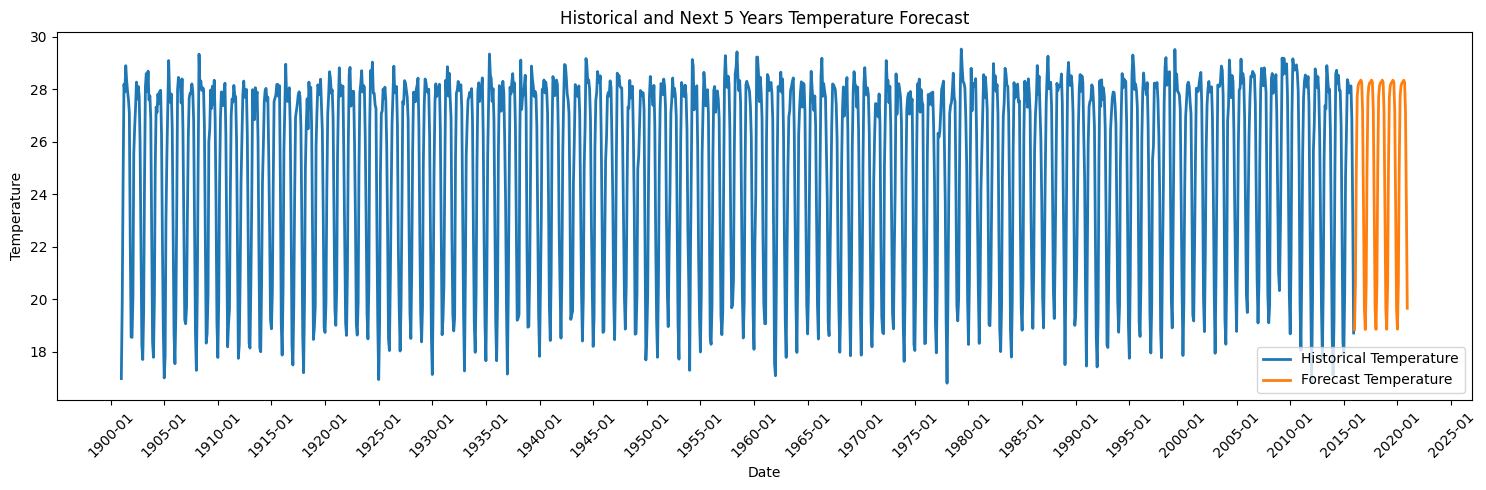

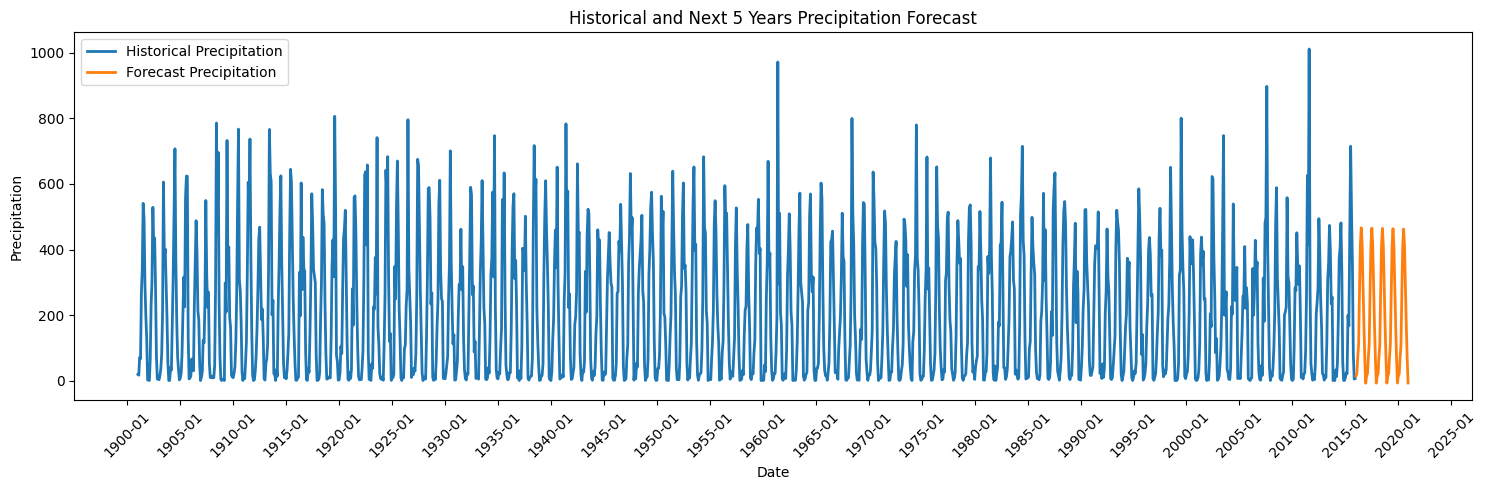

In [3]:
# =====================================================
# 13. FORECAST NEXT 5 YEARS (60 MONTHS)
# =====================================================
future_months = 60

last_date = df["Date"].iloc[-1]

# Create future monthly dates
future_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=1),
    periods=future_months,
    freq="MS"   # Month Start
)

# Create future feature dataframe
future_df = pd.DataFrame({
    "Date": future_dates
})

future_df["Year"] = future_df["Date"].dt.year
future_df["Month"] = future_df["Date"].dt.month
future_df["Month_sin"] = np.sin(2 * np.pi * future_df["Month"] / 12)
future_df["Month_cos"] = np.cos(2 * np.pi * future_df["Month"] / 12)

future_X = future_df[feature_cols]

# Scale future features
future_X_scaled = scaler_X.transform(future_X)

# Combine last known sequence context + future features
all_X_scaled = np.vstack([X_scaled, future_X_scaled])

future_predictions_scaled = []

# Predict month by month
for i in range(future_months):
    start_idx = len(X_scaled) - time_steps + i
    end_idx = len(X_scaled) + i
    
    seq_input = all_X_scaled[start_idx:end_idx]
    seq_input = seq_input.reshape(1, time_steps, X.shape[1])
    
    pred_scaled = model.predict(seq_input, verbose=0)
    future_predictions_scaled.append(pred_scaled[0])

# Convert predictions back to original scale
future_predictions_scaled = np.array(future_predictions_scaled)
future_predictions = scaler_y.inverse_transform(future_predictions_scaled)

# Separate temperature and precipitation forecasts
future_temp = future_predictions[:, 0]
future_prec = future_predictions[:, 1]

# Create results table
future_results = pd.DataFrame({
    "Date": future_dates,
    "Predicted_Temperature": future_temp,
    "Predicted_Precipitation": future_prec
})

print("\nNext 5 Years Forecast")
print(future_results.head())
print(future_results.tail())
# =====================================================
# 16. HISTORICAL + FUTURE TEMPERATURE
# =====================================================
plt.figure(figsize=(15, 5))
plt.plot(df["Date"], df["Temperature"], label="Historical Temperature", linewidth=2)
plt.plot(future_results["Date"], future_results["Predicted_Temperature"], label="Forecast Temperature", linewidth=2)

plt.xlabel("Date")
plt.ylabel("Temperature")
plt.title("Historical and Next 5 Years Temperature Forecast")
plt.legend()

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# =====================================================
# 17. HISTORICAL + FUTURE PRECIPITATION
# =====================================================
plt.figure(figsize=(15, 5))
plt.plot(df["Date"], df["Precipitation"], label="Historical Precipitation", linewidth=2)
plt.plot(future_results["Date"], future_results["Predicted_Precipitation"], label="Forecast Precipitation", linewidth=2)

plt.xlabel("Date")
plt.ylabel("Precipitation")
plt.title("Historical and Next 5 Years Precipitation Forecast")
plt.legend()

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [4]:
#PRedict 2010-2025 and Observe with actual data [LSTM Model]

Train period: 1901-01-01 00:00:00 to 2009-12-01 00:00:00
Test period : 2010-01-01 00:00:00 to 2015-12-01 00:00:00
Train rows  : 1308
Test rows   : 72
X_train_seq shape: (1296, 12, 3)
X_test_seq shape : (72, 12, 3)
Epoch 1/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1029 - val_loss: 0.0141
Epoch 2/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0114 - val_loss: 0.0104
Epoch 3/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0073 - val_loss: 0.0073
Epoch 4/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0053 - val_loss: 0.0070
Epoch 5/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0053 - val_loss: 0.0075
Epoch 6/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0052 - val_loss: 0.0066
Epoch 7/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0047 - val_loss: 0.0063
Epoch 8/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0048 - val_loss: 0.0068
Epoch 9/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0057 - val_loss: 0.0065
Epoch 10/100

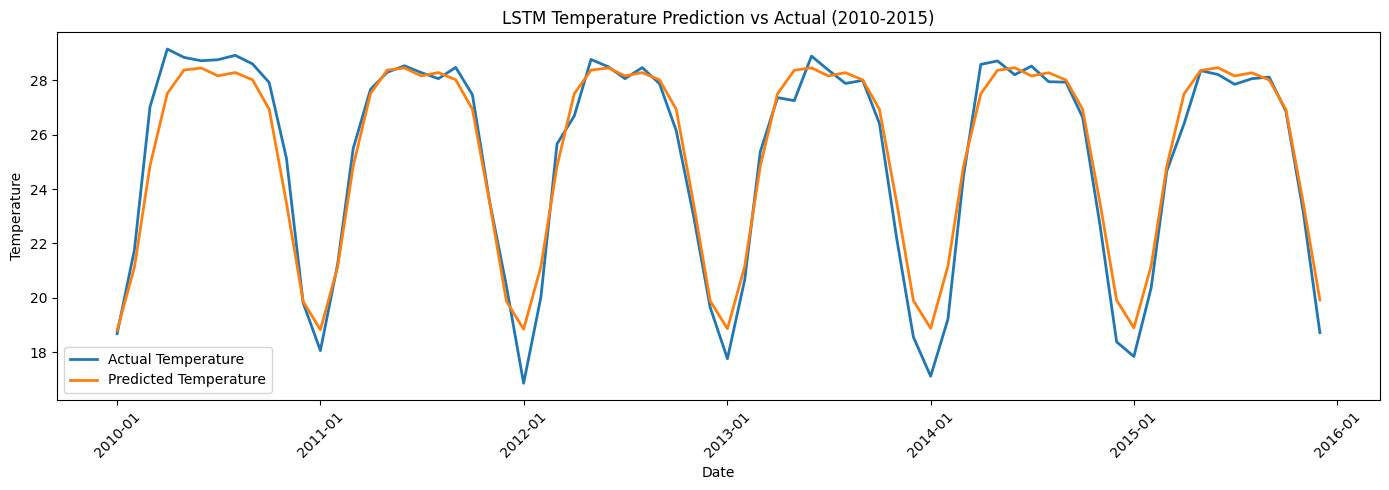

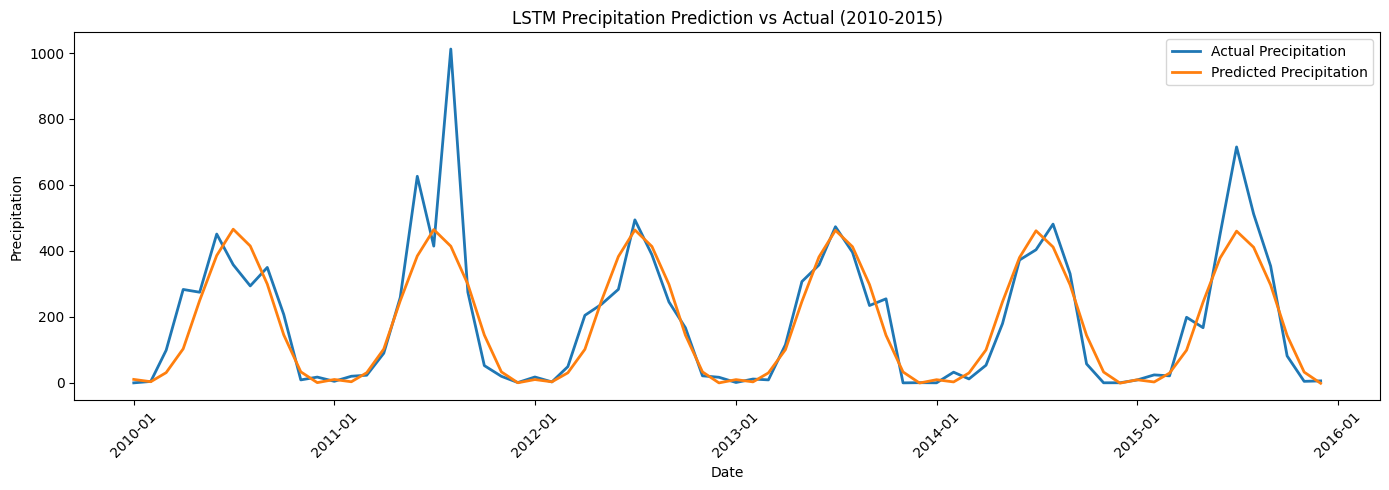

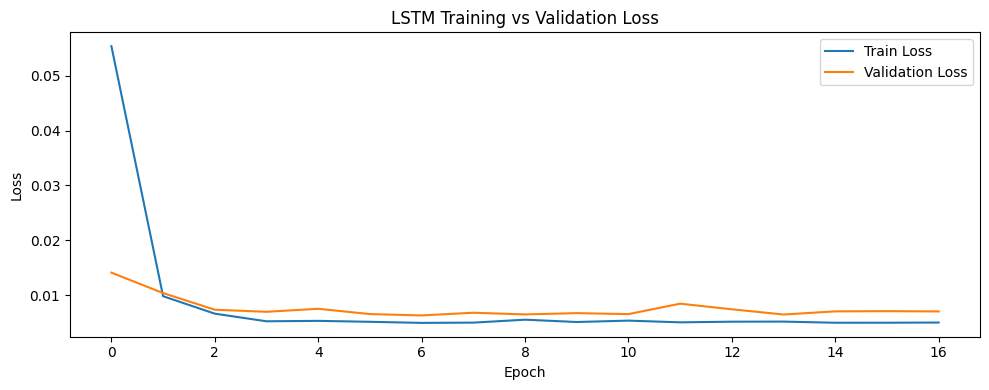


Saved: lstm_2010_2015_actual_vs_predicted.csv


In [5]:
import pandas as pd
import numpy as np
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping


df = pd.read_csv("/kaggle/input/datasets/mdforhadmia/temp-and-rain-csv/Temp_and_rain.csv")

df["Date"] = pd.to_datetime(df[["Year", "Month"]].assign(DAY=1))
df = df.sort_values("Date").reset_index(drop=True)

df["Month_sin"] = np.sin(2 * np.pi * df["Month"] / 12)
df["Month_cos"] = np.cos(2 * np.pi * df["Month"] / 12)

feature_cols = ["Year", "Month_sin", "Month_cos"]
target_cols = ["Temperature", "Precipitation"]

# =====================================================
# 2. TRAIN / TEST PERIOD
#    Train: before 2010
#    Test : 2010-01 to 2015-12
# =====================================================
train_df = df[df["Date"] < "2010-01-01"].copy()
test_df  = df[(df["Date"] >= "2010-01-01") & (df["Date"] <= "2015-12-01")].copy()

print("Train period:", train_df["Date"].min(), "to", train_df["Date"].max())
print("Test period :", test_df["Date"].min(), "to", test_df["Date"].max())
print("Train rows  :", len(train_df))
print("Test rows   :", len(test_df))

# =====================================================
# 3. SCALE USING TRAIN DATA ONLY
# =====================================================
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_base = train_df[feature_cols]
y_train_base = train_df[target_cols]

X_train_scaled = scaler_X.fit_transform(X_train_base)
y_train_scaled = scaler_y.fit_transform(y_train_base)

# To create test sequences properly, we need the 12 months before 2010 too
time_steps = 12

combined_df = df[df["Date"] <= "2015-12-01"].copy()

X_all_scaled = scaler_X.transform(combined_df[feature_cols])
y_all_scaled = scaler_y.transform(combined_df[target_cols])
date_all = combined_df["Date"].reset_index(drop=True)

# =====================================================
# 4. CREATE SEQUENCES
# =====================================================
def create_sequences(X, y, dates, time_steps=12):
    Xs, ys, ds = [], [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:i+time_steps])
        ys.append(y[i+time_steps])
        ds.append(dates.iloc[i+time_steps])
    return np.array(Xs), np.array(ys), np.array(ds)

# Training sequences only from training period
train_dates = train_df["Date"].reset_index(drop=True)
X_train_seq, y_train_seq, train_seq_dates = create_sequences(
    X_train_scaled, y_train_scaled, train_dates, time_steps=time_steps
)

# All sequences up to 2015, then keep only 2010-2015 targets
X_all_seq, y_all_seq, all_seq_dates = create_sequences(
    X_all_scaled, y_all_scaled, date_all, time_steps=time_steps
)

test_mask = (
    (all_seq_dates >= pd.Timestamp("2010-01-01")) &
    (all_seq_dates <= pd.Timestamp("2015-12-01"))
)
X_test_seq = X_all_seq[test_mask]
y_test_seq = y_all_seq[test_mask]
dates_test = all_seq_dates[test_mask]

print("X_train_seq shape:", X_train_seq.shape)
print("X_test_seq shape :", X_test_seq.shape)

# =====================================================
# 5. BUILD LSTM MODEL
# =====================================================
model = Sequential([
    Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    LSTM(64, return_sequences=True),
    LSTM(32),
    Dense(16, activation="relu"),
    Dense(2)
])

model.compile(optimizer="adam", loss="mse")

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# =====================================================
# 6. TRAIN MODEL
# =====================================================

history = model.fit(
    X_train_seq, y_train_seq,
    epochs=100,
    batch_size=16,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# =====================================================
# 7. PREDICT 2010-2015
# =====================================================

y_pred_seq = model.predict(X_test_seq)

# Inverse transform
y_test_inv = scaler_y.inverse_transform(y_test_seq)
y_pred_inv = scaler_y.inverse_transform(y_pred_seq)

temp_actual = y_test_inv[:, 0]
temp_pred   = y_pred_inv[:, 0]

prec_actual = y_test_inv[:, 1]
prec_pred   = y_pred_inv[:, 1]

# =====================================================
# 8. EVALUATION
# =====================================================
def evaluate_model(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    print(f"\n{name}")
    print("-" * 30)
    print(f"R²   : {r2:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")

evaluate_model("Temperature (2010-2015)", temp_actual, temp_pred)
evaluate_model("Precipitation (2010-2015)", prec_actual, prec_pred)

# =====================================================
# 9. RESULTS TABLE
# =====================================================
results_df = pd.DataFrame({
    "Date": dates_test,
    "Actual_Temperature": temp_actual,
    "Predicted_Temperature": temp_pred,
    "Actual_Precipitation": prec_actual,
    "Predicted_Precipitation": prec_pred
})

print(results_df.head())
print(results_df.tail())

# =====================================================
# 10. PLOT TEMPERATURE: ACTUAL VS PREDICTED
# =====================================================
plt.figure(figsize=(14, 5))
plt.plot(results_df["Date"], results_df["Actual_Temperature"], label="Actual Temperature", linewidth=2)
plt.plot(results_df["Date"], results_df["Predicted_Temperature"], label="Predicted Temperature", linewidth=2)

plt.xlabel("Date")
plt.ylabel("Temperature")
plt.title("LSTM Temperature Prediction vs Actual (2010-2015)")
plt.legend()

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# =====================================================
# 11. PLOT PRECIPITATION: ACTUAL VS PREDICTED
# =====================================================
plt.figure(figsize=(14, 5))
plt.plot(results_df["Date"], results_df["Actual_Precipitation"], label="Actual Precipitation", linewidth=2)
plt.plot(results_df["Date"], results_df["Predicted_Precipitation"], label="Predicted Precipitation", linewidth=2)

plt.xlabel("Date")
plt.ylabel("Precipitation")
plt.title("LSTM Precipitation Prediction vs Actual (2010-2015)")
plt.legend()

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# =====================================================
# 12. LOSS CURVE
# =====================================================
plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

# =====================================================
# 13. SAVE RESULTS
# =====================================================
results_df.to_csv("lstm_2010_2015_actual_vs_predicted.csv", index=False)
print("\nSaved: lstm_2010_2015_actual_vs_predicted.csv")

In [6]:
###  Compare predicted and Observed data [ Regression Model]

Train period: 1901-03-01 00:00:00 to 2009-12-01 00:00:00
Test period : 2010-01-01 00:00:00 to 2015-12-01 00:00:00
Train rows  : 1306
Test rows   : 72

Linear Regression Temperature (2010-2015)
------------------------------
R²   : 0.8681
MAE  : 1.1819
RMSE : 1.4049

Linear Regression Precipitation (2010-2015)
------------------------------
R²   : 0.8714
MAE  : 50.4442
RMSE : 74.0267
           Date  Actual_Temperature  Predicted_Temperature  \
1306 2010-01-01             18.6795              20.667416   
1307 2010-02-01             21.7631              21.296188   
1308 2010-03-01             27.0261              24.407173   
1309 2010-04-01             29.1543              27.981162   
1310 2010-05-01             28.8466              30.612779   

      Actual_Precipitation  Predicted_Precipitation  
1306               0.02014               -37.665316  
1307               4.31731                 8.704801  
1308              98.99550               104.950597  
1309             283.1740

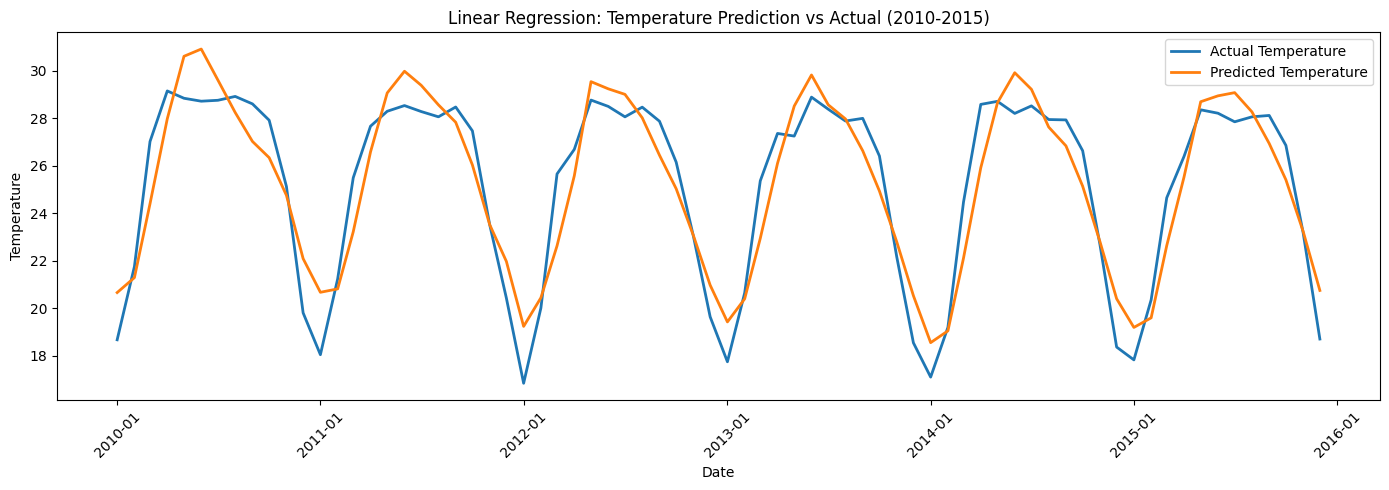

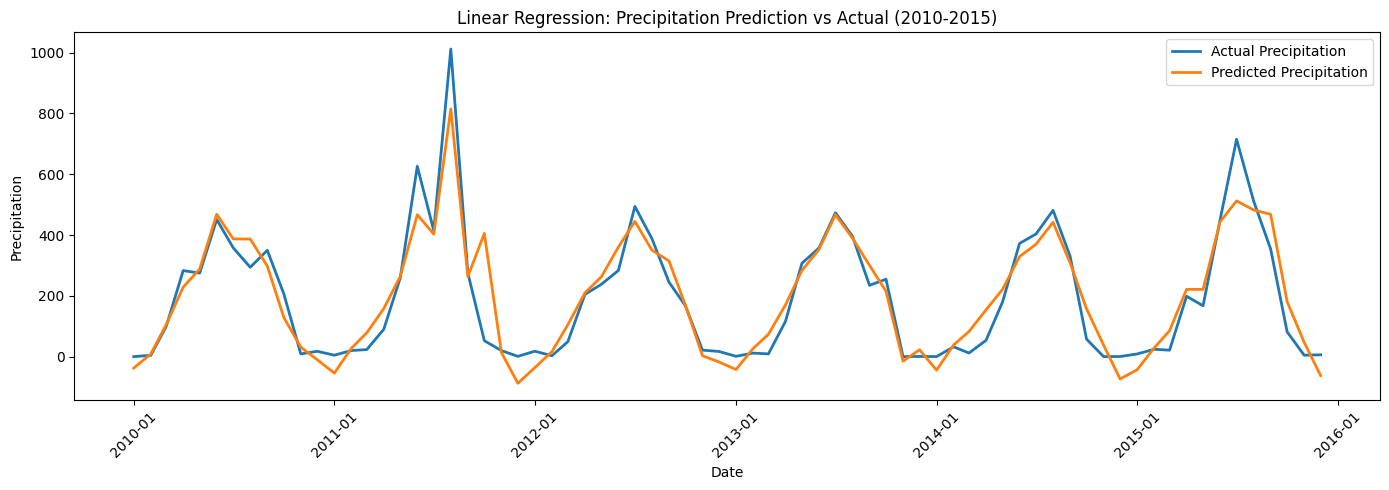


Saved: linear_regression_2010_2015_actual_vs_predicted.csv


In [7]:
import pandas as pd
import numpy as np
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# =====================================================
# 1. LOAD AND PREPARE DATA
# =====================================================
df = pd.read_csv("/kaggle/input/datasets/mdforhadmia/temp-and-rain-csv/Temp_and_rain.csv")

# Create Date column
df["Date"] = pd.to_datetime(df[["Year", "Month"]].assign(DAY=1))

# Sort by time
df = df.sort_values("Date").reset_index(drop=True)

# =====================================================
# 2. FEATURE ENGINEERING
# =====================================================
# Cyclical month encoding
df["Month_sin"] = np.sin(2 * np.pi * df["Month"] / 12)
df["Month_cos"] = np.cos(2 * np.pi * df["Month"] / 12)

# Optional lag features for better regression performance
df["Temp_lag1"] = df["Temperature"].shift(1)
df["Temp_roll3"] = df["Temperature"].rolling(3).mean()

df["Prec_lag1"] = df["Precipitation"].shift(1)
df["Prec_roll3"] = df["Precipitation"].rolling(3).mean()

# Drop NaN caused by lag/rolling
df = df.dropna().reset_index(drop=True)

# =====================================================
# 3. TRAIN / TEST SPLIT BY DATE
# =====================================================
train_df = df[df["Date"] < "2010-01-01"].copy()
test_df  = df[(df["Date"] >= "2010-01-01") & (df["Date"] <= "2015-12-01")].copy()

print("Train period:", train_df["Date"].min(), "to", train_df["Date"].max())
print("Test period :", test_df["Date"].min(), "to", test_df["Date"].max())
print("Train rows  :", len(train_df))
print("Test rows   :", len(test_df))

# =====================================================
# 4. FEATURES AND TARGETS
# =====================================================
feature_cols = [
    "Year", "Month_sin", "Month_cos",
    "Temp_lag1", "Temp_roll3",
    "Prec_lag1", "Prec_roll3"
]

X_train = train_df[feature_cols]
X_test = test_df[feature_cols]

y_train_temp = train_df["Temperature"]
y_test_temp = test_df["Temperature"]

y_train_prec = train_df["Precipitation"]
y_test_prec = test_df["Precipitation"]

dates_test = test_df["Date"]

# =====================================================
# 5. BUILD REGRESSION MODELS
# =====================================================
temp_model = LinearRegression()
prec_model = LinearRegression()

# Train
temp_model.fit(X_train, y_train_temp)
prec_model.fit(X_train, y_train_prec)

# Predict
temp_pred = temp_model.predict(X_test)
prec_pred = prec_model.predict(X_test)

# =====================================================
# 6. EVALUATION
# =====================================================
def evaluate_model(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    print(f"\n{name}")
    print("-" * 30)
    print(f"R²   : {r2:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")

evaluate_model("Linear Regression Temperature (2010-2015)", y_test_temp, temp_pred)
evaluate_model("Linear Regression Precipitation (2010-2015)", y_test_prec, prec_pred)

# =====================================================
# 7. RESULTS TABLE
# =====================================================
results_df = pd.DataFrame({
    "Date": dates_test,
    "Actual_Temperature": y_test_temp.values,
    "Predicted_Temperature": temp_pred,
    "Actual_Precipitation": y_test_prec.values,
    "Predicted_Precipitation": prec_pred
})

print(results_df.head())
print(results_df.tail())

# =====================================================
# 8. PLOT TEMPERATURE
# =====================================================
plt.figure(figsize=(14, 5))
plt.plot(results_df["Date"], results_df["Actual_Temperature"], label="Actual Temperature", linewidth=2)
plt.plot(results_df["Date"], results_df["Predicted_Temperature"], label="Predicted Temperature", linewidth=2)

plt.xlabel("Date")
plt.ylabel("Temperature")
plt.title("Linear Regression: Temperature Prediction vs Actual (2010-2015)")
plt.legend()

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# =====================================================
# 9. PLOT PRECIPITATION
# =====================================================
plt.figure(figsize=(14, 5))
plt.plot(results_df["Date"], results_df["Actual_Precipitation"], label="Actual Precipitation", linewidth=2)
plt.plot(results_df["Date"], results_df["Predicted_Precipitation"], label="Predicted Precipitation", linewidth=2)

plt.xlabel("Date")
plt.ylabel("Precipitation")
plt.title("Linear Regression: Precipitation Prediction vs Actual (2010-2015)")
plt.legend()

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# =====================================================
# 10. SAVE RESULTS
# =====================================================
results_df.to_csv("linear_regression_2010_2015_actual_vs_predicted.csv", index=False)
print("\nSaved: linear_regression_2010_2015_actual_vs_predicted.csv")

In [8]:
### Comparing Actual vs Prediction [Random Forest]

Train period: 1901-03-01 00:00:00 to 2009-12-01 00:00:00
Test period : 2010-01-01 00:00:00 to 2015-12-01 00:00:00
Train rows  : 1306
Test rows   : 72

Random Forest Temperature (2010-2015)
------------------------------
R²   : 0.9842
MAE  : 0.3676
RMSE : 0.4862

Random Forest Precipitation (2010-2015)
------------------------------
R²   : 0.8805
MAE  : 42.0804
RMSE : 71.3755
           Date  Actual_Temperature  Predicted_Temperature  \
1306 2010-01-01             18.6795              18.839539   
1307 2010-02-01             21.7631              22.333219   
1308 2010-03-01             27.0261              25.853037   
1309 2010-04-01             29.1543              28.298728   
1310 2010-05-01             28.8466              28.376934   

      Actual_Precipitation  Predicted_Precipitation  
1306               0.02014                 8.913082  
1307               4.31731                 4.683039  
1308              98.99550                81.435999  
1309             283.17400       

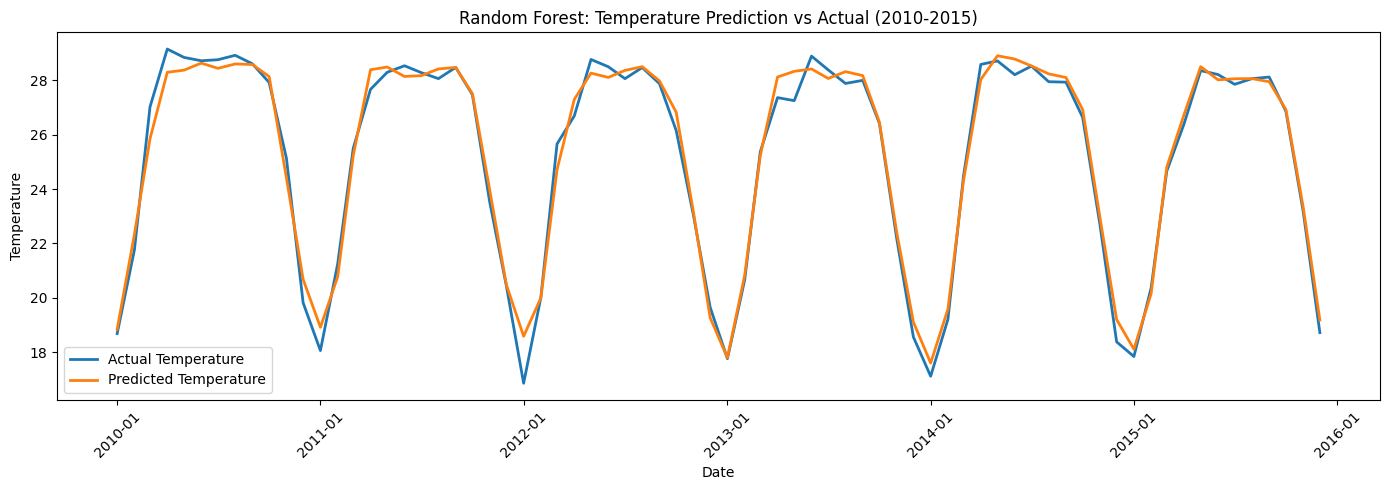

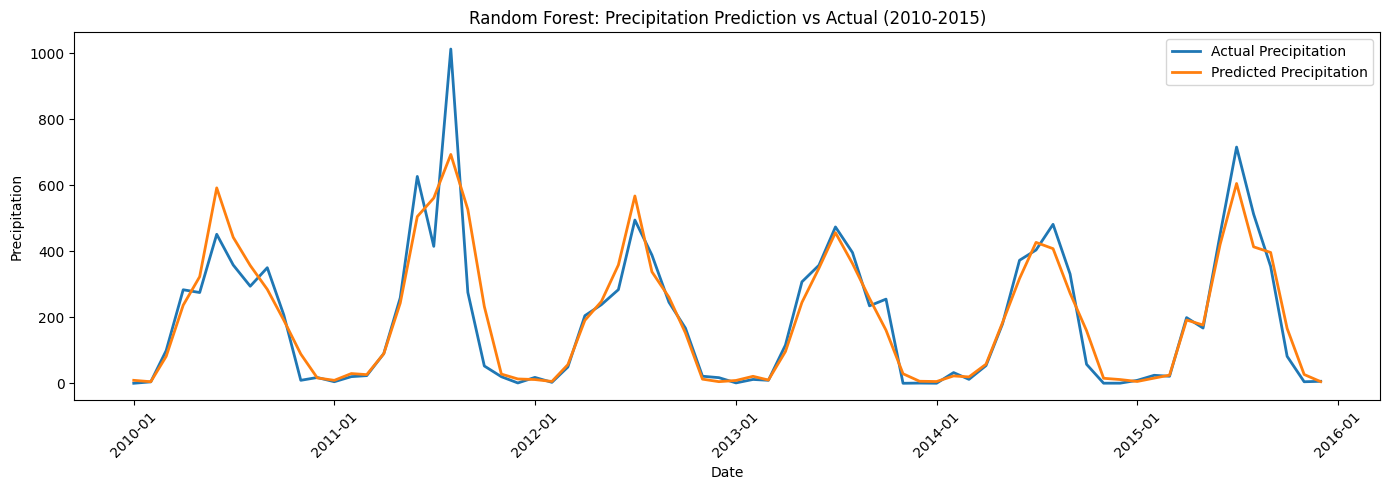


Saved: random_forest_2010_2015_actual_vs_predicted.csv


In [9]:
import pandas as pd
import numpy as np
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# =====================================================
# 1. LOAD AND PREPARE DATA
# =====================================================
df = pd.read_csv("/kaggle/input/datasets/mdforhadmia/temp-and-rain-csv/Temp_and_rain.csv")

# Create Date column
df["Date"] = pd.to_datetime(df[["Year", "Month"]].assign(DAY=1))

# Sort by time
df = df.sort_values("Date").reset_index(drop=True)

# =====================================================
# 2. FEATURE ENGINEERING
# =====================================================
# Cyclical month encoding
df["Month_sin"] = np.sin(2 * np.pi * df["Month"] / 12)
df["Month_cos"] = np.cos(2 * np.pi * df["Month"] / 12)

# Lag and rolling features
df["Temp_lag1"] = df["Temperature"].shift(1)
df["Temp_roll3"] = df["Temperature"].rolling(3).mean()

df["Prec_lag1"] = df["Precipitation"].shift(1)
df["Prec_roll3"] = df["Precipitation"].rolling(3).mean()

# Drop rows with NaN from lag/rolling
df = df.dropna().reset_index(drop=True)

# =====================================================
# 3. TRAIN / TEST SPLIT BY DATE
#    Train: before 2010
#    Test : 2010-01 to 2015-12
# =====================================================
train_df = df[df["Date"] < "2010-01-01"].copy()
test_df  = df[(df["Date"] >= "2010-01-01") & (df["Date"] <= "2015-12-01")].copy()

print("Train period:", train_df["Date"].min(), "to", train_df["Date"].max())
print("Test period :", test_df["Date"].min(), "to", test_df["Date"].max())
print("Train rows  :", len(train_df))
print("Test rows   :", len(test_df))

# =====================================================
# 4. FEATURES AND TARGETS
# =====================================================
feature_cols = [
    "Year", "Month_sin", "Month_cos",
    "Temp_lag1", "Temp_roll3",
    "Prec_lag1", "Prec_roll3"
]

X_train = train_df[feature_cols]
X_test = test_df[feature_cols]

y_train_temp = train_df["Temperature"]
y_test_temp = test_df["Temperature"]

y_train_prec = train_df["Precipitation"]
y_test_prec = test_df["Precipitation"]

dates_test = test_df["Date"]

# =====================================================
# 5. BUILD RANDOM FOREST MODELS
# =====================================================
temp_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

prec_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

# Train
temp_model.fit(X_train, y_train_temp)
prec_model.fit(X_train, y_train_prec)

# Predict
temp_pred = temp_model.predict(X_test)
prec_pred = prec_model.predict(X_test)

# =====================================================
# 6. EVALUATION
# =====================================================
def evaluate_model(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    print(f"\n{name}")
    print("-" * 30)
    print(f"R²   : {r2:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")

evaluate_model("Random Forest Temperature (2010-2015)", y_test_temp, temp_pred)
evaluate_model("Random Forest Precipitation (2010-2015)", y_test_prec, prec_pred)

# =====================================================
# 7. RESULTS TABLE
# =====================================================
results_df = pd.DataFrame({
    "Date": dates_test,
    "Actual_Temperature": y_test_temp.values,
    "Predicted_Temperature": temp_pred,
    "Actual_Precipitation": y_test_prec.values,
    "Predicted_Precipitation": prec_pred
})

print(results_df.head())
print(results_df.tail())

# =====================================================
# 8. PLOT TEMPERATURE
# =====================================================
plt.figure(figsize=(14, 5))
plt.plot(results_df["Date"], results_df["Actual_Temperature"], label="Actual Temperature", linewidth=2)
plt.plot(results_df["Date"], results_df["Predicted_Temperature"], label="Predicted Temperature", linewidth=2)

plt.xlabel("Date")
plt.ylabel("Temperature")
plt.title("Random Forest: Temperature Prediction vs Actual (2010-2015)")
plt.legend()

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# =====================================================
# 9. PLOT PRECIPITATION
# =====================================================
plt.figure(figsize=(14, 5))
plt.plot(results_df["Date"], results_df["Actual_Precipitation"], label="Actual Precipitation", linewidth=2)
plt.plot(results_df["Date"], results_df["Predicted_Precipitation"], label="Predicted Precipitation", linewidth=2)

plt.xlabel("Date")
plt.ylabel("Precipitation")
plt.title("Random Forest: Precipitation Prediction vs Actual (2010-2015)")
plt.legend()

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# =====================================================
# 10. SAVE RESULTS
# =====================================================
results_df.to_csv("random_forest_2010_2015_actual_vs_predicted.csv", index=False)
print("\nSaved: random_forest_2010_2015_actual_vs_predicted.csv")

# **Linear Regression ******# 

Temperature : Linear regression model 
**R2 score : 0.78   Accuracy : 78%**


# Precipitation Prediction : 


# Precipitation R2 Score : 0.87
# accuracy : 87%


# Apply Random Forest Regressor


> Apply random Forest Regressor Model For Temperature

**Now apply LSTM**